In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, 
                             ConfusionMatrixDisplay, roc_auc_score, roc_curve)
from imblearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('always')
warnings.filterwarnings('ignore')

In [75]:
df = pd.read_csv('../data/Processed_HR_Employee_Attrition-v2.csv')

In [76]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df = pd.get_dummies(df, drop_first=True) # drop_first avoids multicollinearity

In [77]:
X = df.drop(columns='Attrition')
y = df['Attrition']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,        # 80% train, 20% test
    random_state=42, 
    stratify=y           # maintain class distribution
)

In [79]:
print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

Train size: 1176 | Test size: 294


In [96]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        penalty='l2',
        C=0.5,              # 🔽 stronger regularization
        class_weight='balanced',
        solver='liblinear',  # good for small datasets 
        random_state=42, 
        max_iter=2000
    ))
])


In [97]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [98]:
from sklearn.model_selection import cross_val_predict

y_train_proba = cross_val_predict(
    pipeline, 
    X_train, 
    y_train, 
    cv=skf, 
    method='predict_proba'
)[:, 1]

In [99]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_train, y_train_proba)

In [100]:
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best Threshold: {best_threshold:.4f}")
print(f"Best F1 Score : {f1_scores[best_idx]:.4f}")

Best Threshold: 0.5783
Best F1 Score : 0.5800


In [101]:
pipeline.fit(X_train, y_train)

y_test_proba = pipeline.predict_proba(X_test)[:, 1]
y_test_pred  = (y_test_proba >= best_threshold).astype(int)

In [102]:
print("\n── Threshold Tuned Report ──")
print(classification_report(y_test, y_test_pred))


── Threshold Tuned Report ──
              precision    recall  f1-score   support

           0       0.93      0.78      0.85       255
           1       0.29      0.59      0.39        39

    accuracy                           0.76       294
   macro avg       0.61      0.69      0.62       294
weighted avg       0.84      0.76      0.79       294



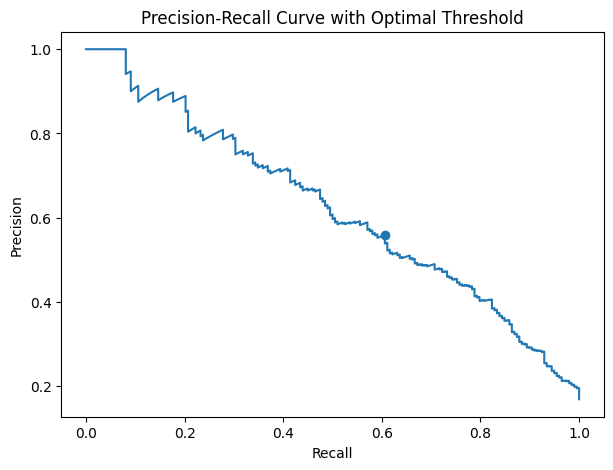

In [95]:
plt.figure(figsize=(7,5))
plt.plot(recall, precision)
plt.scatter(recall[best_idx], precision[best_idx], marker='o')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve with Optimal Threshold")
plt.show()

In [106]:
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_test_pred):.4f}")

ROC-AUC Score: 0.6851


<Figure size 600x500 with 0 Axes>

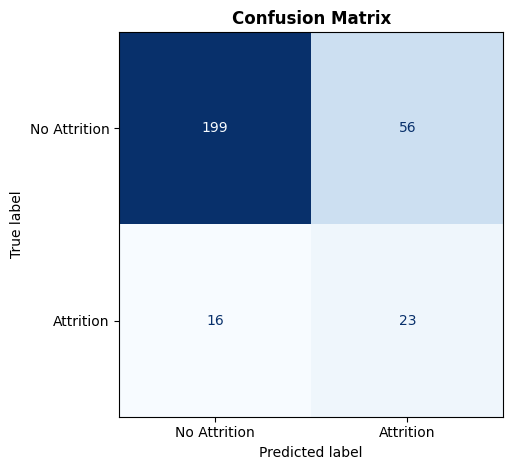

In [107]:
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Attrition', 'Attrition'])

plt.figure(figsize=(6, 5))
disp.plot(cmap='Blues', colorbar=False)
plt.title("Confusion Matrix", fontweight='black')
plt.tight_layout()
plt.show()


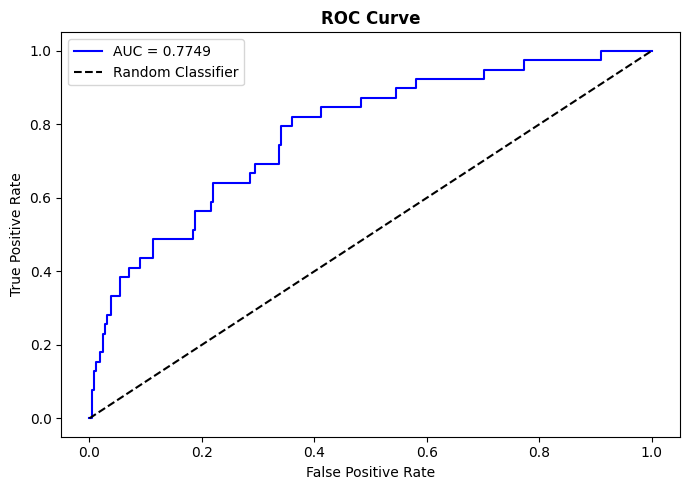

In [108]:
fpr, tpr, _ = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc_score(y_test, y_proba):.4f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve', fontweight='black')
plt.legend()
plt.tight_layout()
plt.show()